# CLO 1 - CB Exercise: Histogram Citra

**Citra**: 16×16 piksel, level keabuan 0–31 (32 level)

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

image = np.array([
    [ 0, 10,  1,  8,  1,  8,  8,  1,  8, 29, 25,  1, 24,  0,  0, 24],
    [ 8,  0,  8,  1, 28,  0, 10,  1, 10,  0, 25, 11, 25,  0, 24, 15],
    [29, 10, 29, 28, 28, 29, 28,  1,  8, 22, 29, 25,  1, 24,  0, 15],
    [ 3, 10,  3,  1,  5,  0,  3,  6,  1,  6,  1, 25, 29,  6, 14, 26],
    [28,  0, 28, 29,  1,  1, 10, 15, 29, 22, 22,  1, 25,  0, 14, 26],
    [28,  1, 29, 10, 10,  1, 10,  1, 21,  0, 14, 14, 29, 26,  0, 15],
    [29, 28, 28,  0, 12, 29,  3, 21, 29, 14,  1, 29, 26, 26, 29, 26],
    [29, 30,  3,  1,  5,  0,  1,  6,  8,  6, 22, 11,  1,  6, 26, 26],
    [ 3,  0, 29, 12, 12, 21, 12, 11,  1, 11,  0, 22, 29, 24,  0, 18],
    [29,  1, 29, 29, 12, 29,  3,  0, 29, 20, 20,  1, 23, 29, 27, 20],
    [29, 30,  3,  0,  4, 12, 20, 21,  7, 20,  1, 29, 20,  6, 27, 27],
    [ 3, 30, 30, 12,  1, 21,  0, 13, 11,  6, 13,  7, 23, 19, 27, 18],
    [30,  0, 30, 29, 12, 29,  1, 21, 29, 29, 13,  1, 29, 19,  0, 18],
    [ 3, 30,  3,  0, 21, 12,  3,  0,  7,  7,  0,  7,  1, 23, 18, 18],
    [29,  1, 29, 21,  1, 29, 31,  1, 29, 13, 13,  7, 17, 24,  0, 27],
    [ 3,  0, 30, 21,  0, 30, 30,  1, 13,  0, 13,  7, 17, 17,  0, 27]
], dtype=np.uint8)

MAX_LEVEL = 32
N = image.size  # 256 piksel
pixels = image.flatten()

print(f'Ukuran citra : {image.shape[0]}x{image.shape[1]}')
print(f'Total piksel : {N}')
print(f'Nilai min    : {pixels.min()}')
print(f'Nilai max    : {pixels.max()}')
print(f'Level keabuan: {MAX_LEVEL} (0–{MAX_LEVEL-1})')

Ukuran citra : 16x16
Total piksel : 256
Nilai min    : 0
Nilai max    : 31
Level keabuan: 32 (0–31)



### 1a. Jumlah Bin = 16 (lebar bin = 2)

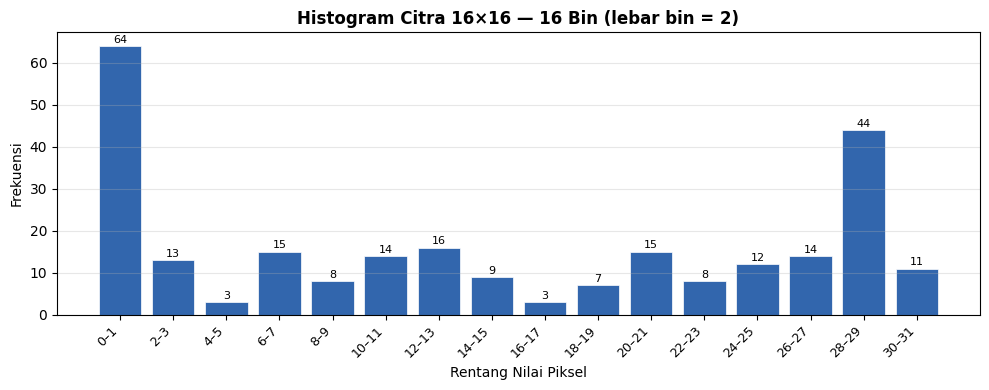


Tabel Histogram 16 Bin:
 Bin   Rentang    f(r)      p(r)
----------------------------------
   0       0–1      64    0.2500
   1       2–3      13    0.0508
   2       4–5       3    0.0117
   3       6–7      15    0.0586
   4       8–9       8    0.0312
   5     10–11      14    0.0547
   6     12–13      16    0.0625
   7     14–15       9    0.0352
   8     16–17       3    0.0117
   9     18–19       7    0.0273
  10     20–21      15    0.0586
  11     22–23       8    0.0312
  12     24–25      12    0.0469
  13     26–27      14    0.0547
  14     28–29      44    0.1719
  15     30–31      11    0.0430
TOTAL               256    1.0000


In [ ]:
def compute_histogram(pixels, num_bins, max_level=32):
    """Hitung histogram dengan num_bins bin."""
    bin_size = max_level // num_bins
    hist = np.zeros(num_bins, dtype=int)
    for p in pixels:
        idx = min(int(p) // bin_size, num_bins - 1)
        hist[idx] += 1
    return hist, bin_size

def get_bin_labels(num_bins, max_level=32):
    bin_size = max_level // num_bins
    return [f'{i*bin_size}–{i*bin_size+bin_size-1}' for i in range(num_bins)]

def print_hist_table(hist, num_bins, max_level=32):
    bin_size = max_level // num_bins
    N = hist.sum()
    print(f'{'Bin':>4}  {'Rentang':>8}  {'f(r)':>6}  {'p(r)':>8}')
    print('-' * 34)
    for i, count in enumerate(hist):
        label = f'{i*bin_size}–{i*bin_size+bin_size-1}'
        prob = count / N
        print(f'{i:>4}  {label:>8}  {count:>6}  {prob:>8.4f}')
    print(f'{'TOTAL':>4}  {'':>8}  {N:>6}  {1.0:>8.4f}')

# Histogram 16 bin
hist16, bs16 = compute_histogram(pixels, 16)
labels16 = get_bin_labels(16)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(16), hist16, color='#3266ad', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(16))
ax.set_xticklabels(labels16, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Rentang Nilai Piksel')
ax.set_ylabel('Frekuensi')
ax.set_title('Histogram Citra 16×16 — 16 Bin (lebar bin = 2)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, hist16):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('histogram_16bin.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTabel Histogram 16 Bin:')
print_hist_table(hist16, 16)

### 1b. Jumlah Bin = 8 (lebar bin = 4)

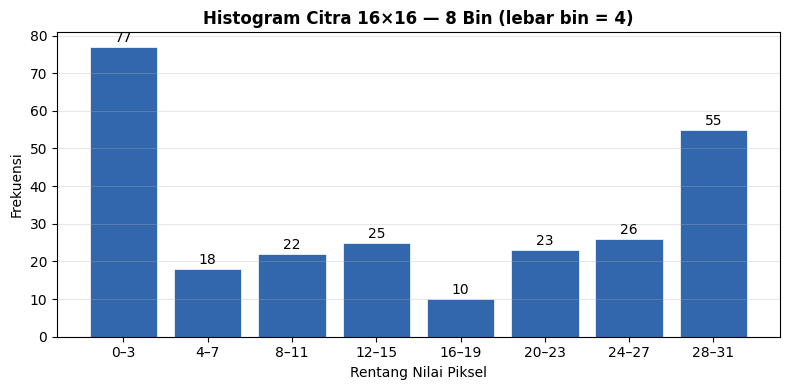


Tabel Histogram 8 Bin:
 Bin   Rentang    f(r)      p(r)
----------------------------------
   0       0–3      77    0.3008
   1       4–7      18    0.0703
   2      8–11      22    0.0859
   3     12–15      25    0.0977
   4     16–19      10    0.0391
   5     20–23      23    0.0898
   6     24–27      26    0.1016
   7     28–31      55    0.2148
TOTAL               256    1.0000


In [9]:
hist8, bs8 = compute_histogram(pixels, 8)
labels8 = get_bin_labels(8)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(8), hist8, color='#3266ad', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(8))
ax.set_xticklabels(labels8, rotation=0, fontsize=10)
ax.set_xlabel('Rentang Nilai Piksel')
ax.set_ylabel('Frekuensi')
ax.set_title('Histogram Citra 16×16 — 8 Bin (lebar bin = 4)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, hist8):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('histogram_8bin.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTabel Histogram 8 Bin:')
print_hist_table(hist8, 8)

### 1c. Jumlah Bin = 4 (lebar bin = 8)

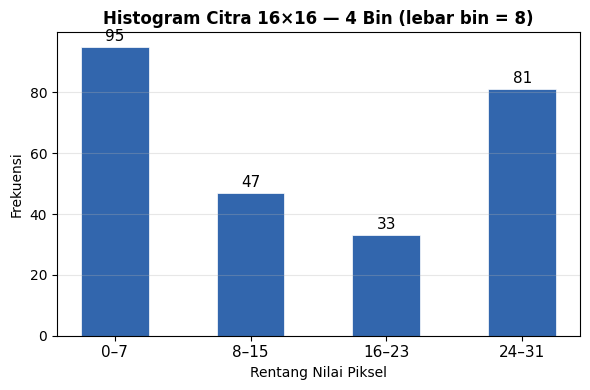


Tabel Histogram 4 Bin:
 Bin   Rentang    f(r)      p(r)
----------------------------------
   0       0–7      95    0.3711
   1      8–15      47    0.1836
   2     16–23      33    0.1289
   3     24–31      81    0.3164
TOTAL               256    1.0000


In [4]:
hist4, bs4 = compute_histogram(pixels, 4)
labels4 = get_bin_labels(4)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(range(4), hist4, color='#3266ad', edgecolor='white', linewidth=0.5, width=0.5)
ax.set_xticks(range(4))
ax.set_xticklabels(labels4, fontsize=11)
ax.set_xlabel('Rentang Nilai Piksel')
ax.set_ylabel('Frekuensi')
ax.set_title('Histogram Citra 16×16 — 4 Bin (lebar bin = 8)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, hist4):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('histogram_4bin.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTabel Histogram 4 Bin:')
print_hist_table(hist4, 4)


## Soal 2 — Ekualisasi Histogram (dari histogram 8 bin)

Tabel Proses Ekualisasi Histogram (8 Bin):
 Bin  Rentang   f(r)     p(r)      CDF  s=round(CDF×7)  Bin Hasil
----------------------------------------------------------------------
   0      0–3     77   0.3008   0.3008               2       8–11
   1      4–7     18   0.0703   0.3711               3      12–15
   2     8–11     22   0.0859   0.4570               3      12–15
   3    12–15     25   0.0977   0.5547               4      16–19
   4    16–19     10   0.0391   0.5938               4      16–19
   5    20–23     23   0.0898   0.6836               5      20–23
   6    24–27     26   0.1016   0.7852               5      20–23
   7    28–31     55   0.2148   1.0000               7      28–31


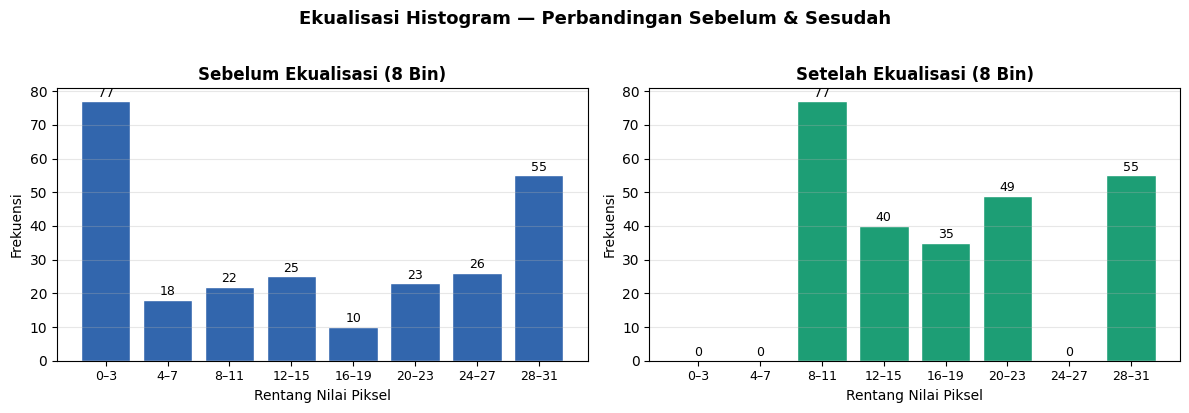


Histogram hasil ekualisasi: [0, 0, 77, 40, 35, 49, 0, 55]
Total piksel (verifikasi) : 256


In [10]:
# Use histogram 8 bin
num_bins = 8
hist = hist8.copy()
L = num_bins

# 1. Hitung probabilitas tiap bin
prob = hist / N

# 2. Hitung CDF
cdf = np.cumsum(prob)

# 3. Mapping: s_k = round(CDF * (L-1))
mapping = np.round(cdf * (L - 1)).astype(int)
mapping = np.clip(mapping, 0, L - 1)

# 4. Hitung histogram hasil ekualisasi
hist_eq = np.zeros(num_bins, dtype=int)
for i, m in enumerate(mapping):
    hist_eq[m] += hist[i]

# Tabel proses
print('Tabel Proses Ekualisasi Histogram (8 Bin):')
print(f"{'Bin':>4} {'Rentang':>8} {'f(r)':>6} {'p(r)':>8} {'CDF':>8} {'s=round(CDF×7)':>15} {'Bin Hasil':>10}")
print('-' * 70)
for i in range(num_bins):
    bin_size = MAX_LEVEL // num_bins
    label = f'{i*bin_size}–{i*bin_size+bin_size-1}'
    print(f"{i:>4} {label:>8} {hist[i]:>6} {prob[i]:>8.4f} {cdf[i]:>8.4f} {mapping[i]:>15} {labels8[mapping[i]]:>10}")

# Plot perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sebelum
bars1 = axes[0].bar(range(num_bins), hist, color='#3266ad', edgecolor='white')
axes[0].set_xticks(range(num_bins))
axes[0].set_xticklabels(labels8, rotation=0, fontsize=9)
axes[0].set_title('Sebelum Ekualisasi (8 Bin)', fontweight='bold')
axes[0].set_xlabel('Rentang Nilai Piksel')
axes[0].set_ylabel('Frekuensi')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, hist):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=9)

# Sesudah
bars2 = axes[1].bar(range(num_bins), hist_eq, color='#1D9E75', edgecolor='white')
axes[1].set_xticks(range(num_bins))
axes[1].set_xticklabels(labels8, rotation=0, fontsize=9)
axes[1].set_title('Setelah Ekualisasi (8 Bin)', fontweight='bold')
axes[1].set_xlabel('Rentang Nilai Piksel')
axes[1].set_ylabel('Frekuensi')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, hist_eq):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Ekualisasi Histogram — Perbandingan Sebelum & Sesudah', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('histogram_ekualisasi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nHistogram hasil ekualisasi:', hist_eq.tolist())
print('Total piksel (verifikasi) :', hist_eq.sum())


## Soal 3 — Spesifikasi Histogram (dari histogram 8 bin)

Histogram target yang diinginkan: Distribusi Gaussian (lonceng), bobot `[4, 10, 30, 60, 60, 30, 10, 4]`

Metode: Cocokkan CDF sumber dengan CDF target untuk tiap bin sumber, cari bin target dengan CDF terdekat

Tabel Proses Spesifikasi Histogram:
 Bin  Rentang   f(r)   CDF src   CDF tgt  Bin Hasil  Rentang Hasil
----------------------------------------------------------------------
   0      0–3     77    0.3008    0.2115          2           8–11
   1      4–7     18    0.3711    0.5000          3          12–15
   2     8–11     22    0.4570    0.5000          3          12–15
   3    12–15     25    0.5547    0.5000          3          12–15
   4    16–19     10    0.5938    0.5000          3          12–15
   5    20–23     23    0.6836    0.7885          4          16–19
   6    24–27     26    0.7852    0.7885          4          16–19
   7    28–31     55    1.0000    1.0000          7          28–31


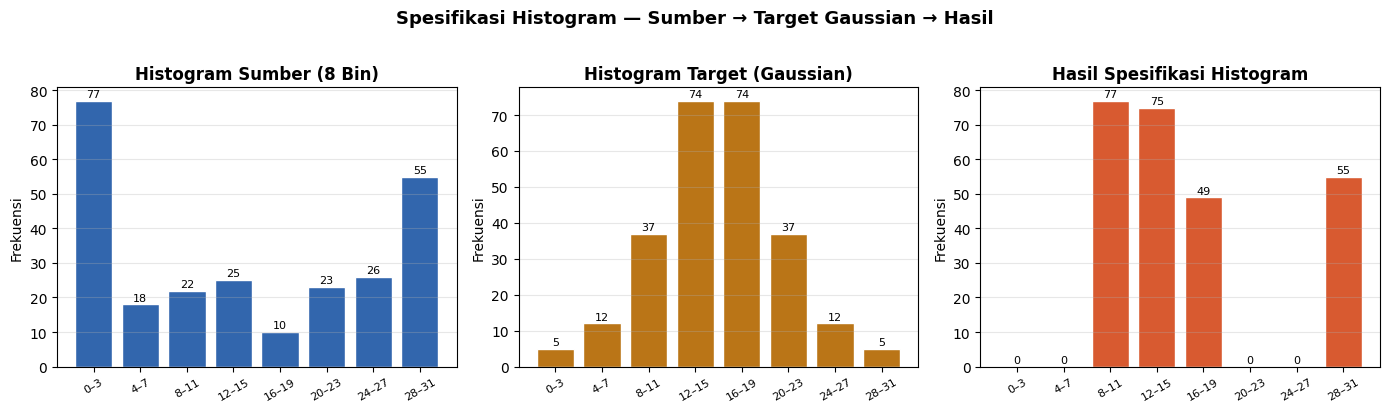


Histogram hasil spesifikasi: [0, 0, 77, 75, 49, 0, 0, 55]
Total piksel (verifikasi)  : 256


In [6]:
# Histogram target: distribusi Gaussian simetris
target_weights = np.array([4, 10, 30, 60, 60, 30, 10, 4], dtype=float)
target_norm = target_weights / target_weights.sum()  # normalisasi ke probabilitas
target_counts = np.round(target_norm * N).astype(int)  # skala ke 256 piksel

# CDF sumber
prob_src = hist8 / N
cdf_src  = np.cumsum(prob_src)

# CDF target
cdf_tgt = np.cumsum(target_norm)

# Mapping: untuk tiap bin sumber, cari bin target dgn CDF terdekat
mapping_sp = np.zeros(num_bins, dtype=int)
for i in range(num_bins):
    diffs = np.abs(cdf_tgt - cdf_src[i])
    mapping_sp[i] = np.argmin(diffs)

# Histogram hasil spesifikasi
hist_sp = np.zeros(num_bins, dtype=int)
for i, m in enumerate(mapping_sp):
    hist_sp[m] += hist8[i]

# Tabel proses
print('Tabel Proses Spesifikasi Histogram:')
print(f"{'Bin':>4} {'Rentang':>8} {'f(r)':>6} {'CDF src':>9} {'CDF tgt':>9} {'Bin Hasil':>10} {'Rentang Hasil':>14}")
print('-' * 70)
for i in range(num_bins):
    bin_size = MAX_LEVEL // num_bins
    label = f'{i*bin_size}–{i*bin_size+bin_size-1}'
    m = mapping_sp[i]
    print(f"{i:>4} {label:>8} {hist8[i]:>6} {cdf_src[i]:>9.4f} {cdf_tgt[m]:>9.4f} {m:>10} {labels8[m]:>14}")

# Plot perbandingan 3 panel
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Sumber
b1 = axes[0].bar(range(num_bins), hist8, color='#3266ad', edgecolor='white')
axes[0].set_xticks(range(num_bins)); axes[0].set_xticklabels(labels8, rotation=30, fontsize=8)
axes[0].set_title('Histogram Sumber (8 Bin)', fontweight='bold')
axes[0].set_ylabel('Frekuensi'); axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(b1, hist8):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(val), ha='center', va='bottom', fontsize=8)

# Target
b2 = axes[1].bar(range(num_bins), target_counts, color='#BA7517', edgecolor='white')
axes[1].set_xticks(range(num_bins)); axes[1].set_xticklabels(labels8, rotation=30, fontsize=8)
axes[1].set_title('Histogram Target (Gaussian)', fontweight='bold')
axes[1].set_ylabel('Frekuensi'); axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(b2, target_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(val), ha='center', va='bottom', fontsize=8)

# Hasil
b3 = axes[2].bar(range(num_bins), hist_sp, color='#D85A30', edgecolor='white')
axes[2].set_xticks(range(num_bins)); axes[2].set_xticklabels(labels8, rotation=30, fontsize=8)
axes[2].set_title('Hasil Spesifikasi Histogram', fontweight='bold')
axes[2].set_ylabel('Frekuensi'); axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(b3, hist_sp):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(val), ha='center', va='bottom', fontsize=8)

plt.suptitle('Spesifikasi Histogram — Sumber → Target Gaussian → Hasil', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('histogram_spesifikasi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nHistogram hasil spesifikasi:', hist_sp.tolist())
print('Total piksel (verifikasi)  :', hist_sp.sum())